<a href="https://colab.research.google.com/github/jyothisasidharan/ML_AI_Projects/blob/main/Sentiment_Analysis_of_Corona_Tweets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english')) # they exist only for english

print(stop_words)

{"they've", "wasn't", 'themselves', 'been', 'these', "we'd", 'theirs', 'd', 'after', 'not', 'm', 'how', 'him', 'she', "couldn't", "you're", "it'd", 'few', 's', 'they', 're', "you'd", 'only', "should've", 'where', 'didn', 'them', 'most', 'too', 'himself', 'yourself', 'our', 'had', 'hasn', "he's", 'to', "hadn't", 'down', "isn't", 'why', "i'll", 'an', 'won', 'your', 'from', 'when', 'we', 'what', "he'll", "weren't", 'now', 'herself', 'off', 've', "she'd", 'should', 'is', 'just', "wouldn't", 'it', 'weren', 'below', 'against', 'yours', 'but', "i'm", 't', 'o', 'this', 'as', "haven't", 'further', 'me', 'then', 'while', "shan't", "shouldn't", 'my', 'if', 'did', 'other', 'myself', 'in', "it'll", 'because', 'before', 'up', 'once', 'who', 'do', 'same', 'between', 'over', 'their', 'again', 'there', 'isn', 'her', 'have', 'll', 'doing', "hasn't", 'haven', 'his', 'yourselves', "mustn't", 'any', 'its', 'ma', 'aren', 'own', "you'll", 'above', 'does', 'needn', 'nor', 'at', 'here', "mightn't", 'during', '

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


1. let's eat grandma.
2. let's eat, grandma.

# Let's talk about basic pre-processing

1.   PorterStemmer: This is an algorithm for removing suffixes from words to reduce them to their root form (stem). It's a heuristic process that doesn't consider the meaning of the word or ensure that the resulting stem is a valid word. For example, "running," "runs," and "ran" might all be reduced to "run." It's generally faster but less accurate than lemmatization.


2.   WordNetLemmatizer: This is a lemmatization technique that uses the WordNet lexical database to find the base or dictionary form (lemma) of a word. Unlike stemming, lemmatization considers the word's context and part of speech to produce a valid word. For example, the lemma of "better" is "good," and the lemma of "running" (as a verb) is "run." It's generally more accurate but can be slower than stemming.

WordNet is a large lexical database of English. Nouns, verbs, adjectives and adverbs are grouped into sets of cognitive synonyms (synsets), each expressing a distinct concept. Synsets are interlinked by means of conceptual-semantic and lexical relations.

In essence, WordNet can be thought of as a dictionary, but with a much richer structure that links words based on their meaning. It is widely used in natural language processing for tasks like word sense disambiguation, information retrieval, and machine translation.



In [104]:
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Ensure you have the necessary resources downloaded
nltk.download('wordnet')
nltk.download('omw-1.4')# omw is the Open Multilingual

from nltk.corpus import wordnet as wn
wn.synsets('dog')                 # list of sense objects
wn.synsets('cat')[0].definition()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


'feline mammal usually having thick soft fur and no ability to roar: domestic cats; wildcats'

In [105]:
import os
import re
import random
import string      # for string operations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import plotly.express as px
# SetUp NLTK
!pip install --user -U nltk
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [106]:
!gdown 11LWo5nagSmC72hOJM9lm2l05sdQxt4rf


Downloading...
From: https://drive.google.com/uc?id=11LWo5nagSmC72hOJM9lm2l05sdQxt4rf
To: /content/corona_tweets.csv
100% 1.00M/1.00M [00:00<00:00, 110MB/s]


In [107]:
import pandas as pd

!gdown 11LWo5nagSmC72hOJM9lm2l05sdQxt4rf
dataframe = pd.read_csv("./corona_tweets.csv")
dataframe.head()

Downloading...
From: https://drive.google.com/uc?id=11LWo5nagSmC72hOJM9lm2l05sdQxt4rf
To: /content/corona_tweets.csv
100% 1.00M/1.00M [00:00<00:00, 102MB/s]


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral


In [108]:
dataframe.loc[dataframe['Sentiment'] == 'Negative'].loc[3].OriginalTweet

'#Panic buying hits #NewYork City as anxious shoppers stock up on food&amp;medical supplies after #healthcare worker in her 30s becomes #BigApple 1st confirmed #coronavirus patient OR a #Bloomberg staged event?\r\r\n\r\r\nhttps://t.co/IASiReGPC4\r\r\n\r\r\n#QAnon #QAnon2018 #QAnon2020 \r\r\n#Election2020 #CDC https://t.co/29isZOewxu'

In [109]:
import plotly.express as px
fig = px.pie(dataframe, names='Sentiment',hole=0.3, title='Sentiment Pie Chart')
fig.show()

In [110]:
missing_values = dataframe.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
UserName           0
ScreenName         0
Location         834
TweetAt            0
OriginalTweet      0
Sentiment          0
dtype: int64


Labels in the dataset:  ['Extremely Negative' 'Positive' 'Extremely Positive' 'Negative' 'Neutral']
Sentiment
Negative              1041
Positive               947
Neutral                619
Extremely Positive     599
Extremely Negative     592
Name: count, dtype: int64


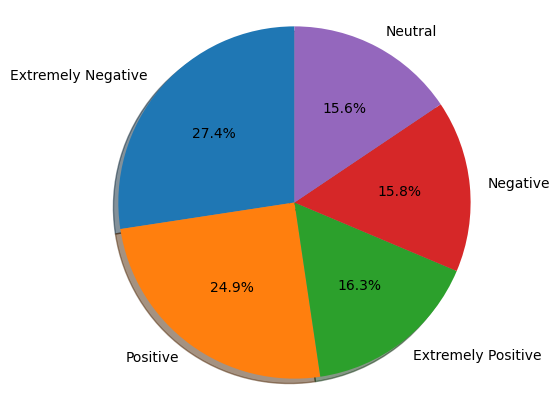

In [111]:
import matplotlib.pyplot as plt

# Check tweets distribution
def pie_chart(dataframe):
  # Converting pd object to list of string
  label_types  = dataframe.Sentiment.unique().astype(str)
  # Count tweets for each label
  label_counts = dataframe.Sentiment.value_counts()
  print('Labels in the dataset: ', label_types)
  print(label_counts)
  # labels for the two classes
  labels = label_types #'Positives', 'Negative'
  # Sizes for each slide
  sizes = [count for count in label_counts]
  # Declare a figure with a custom size
  fig = plt.figure(figsize=(5, 5))
  # Declare pie chart, where the slices will be ordered and plotted counter-clockwise:
  plt.pie(sizes, labels=labels, autopct='%1.1f%%',
          shadow=True, startangle=90)
  # Equal aspect ratio ensures that pie is drawn as a circle.
  plt.axis('equal')
  # Display the chart
  plt.show()

pie_chart(dataframe)

# Let's start with dataset creation.

In [112]:
dataframe[dataframe['Sentiment'] == 'Negative']['OriginalTweet'].shape


(1041,)

In [113]:
dataframe[dataframe['Sentiment'] == 'Positive']['OriginalTweet'].shape


(947,)

In [114]:
list(dataframe[dataframe['Sentiment'] == 'Positive']['OriginalTweet'].astype(str))[:5]

["When I couldn't find hand sanitizer at Fred Meyer, I turned to #Amazon. But $114.97 for a 2 pack of Purell??!!Check out how  #coronavirus concerns are driving up prices. https://t.co/ygbipBflMY",
 'Voting in the age of #coronavirus = hand sanitizer ? #SuperTuesday https://t.co/z0BeL4O6Dk',
 'Best quality couches at unbelievably low prices available to order.\r\r\n\r\r\nWe are in Boksburg GP \r\r\n\r\r\nFor more info WhatsApp:\r\r\n084 764 8086\r\r\n\r\r\n#SuperTuesdsy #PowerTalk \r\r\n#Covid_19 #SayEntrepreneur \r\r\n#DJSBU https://t.co/HhDJhyQ2Dc',
 'While we were busy watching election returns and bracing for a Covid-19 outbreak, Trump nominated a chemical-industry lobbyist to head the Consumer Product Safety Commission https://t.co/M2ShHI1Tn0',
 "That's about a week from now. A bit optimistic.  Probably it will take another month.  Supply chain may be recovering, demand chain will be non-existent in US and Europe for the next month or two.\r\r\n$spx $qqq $es $nq https://t.co/yXcOf

In [115]:
# Separating positive_tweets and negative_tweets
all_positive_tweets = list(dataframe[dataframe['Sentiment'] == 'Positive']['OriginalTweet'].astype(str)) # Making equal positive and negative tweet counts
all_negative_tweets = list(dataframe[dataframe['Sentiment'] == 'Negative']['OriginalTweet'].astype(str))[:947]

In [116]:
from sklearn.model_selection import train_test_split

# Splitting training and testing set. 80/20 split
positive_train, positive_test = train_test_split(all_positive_tweets, test_size=0.2, random_state=42)
negative_train, negative_test = train_test_split(all_negative_tweets, test_size=0.2, random_state=42)

In [117]:

print("Size of training dataset: ",len(positive_train) + len(negative_train))
print("Size of testing dataset: ", len(positive_test)  + len(negative_test))

Size of training dataset:  1514
Size of testing dataset:  380


In [118]:
import random

print('\033[92m' + '\npositive in green: ')
print('\033[92m' + all_positive_tweets[random.randint(0,947)])
print('\033[91m' + '\nnegative in red: ')
# print negative in red
print('\033[91m' + all_negative_tweets[random.randint(0,947)])


positive in green: 
@ShopprsDrugMart hiking their prices to almost 300% of regular price for toilet paper amid #Covid_19 pandemic is pretty sleazy business if you ask me.

negative in red: 
Oil prices at an all time low, Alberta's 3rd winter + Coronavirus madness. I tap world - You Win ! #Covid_19 #oilprice #toiletpapercrisis #albertarecession


## Some basic tokenization of words

In [119]:
# Split on spaces
tweet = all_positive_tweets[12]
print(type(tweet))

print("This is sample tweet: ", tweet)
word = tweet.split() # space tokenizer
print('Using Split :',word)

<class 'str'>
This is sample tweet:  Consumers have increased their online shopping due to coronavirus. https://t.co/5mYfz3RAD0 #retail #ecommerce #study #coronavirus https://t.co/Dz3H6zrWUT
Using Split : ['Consumers', 'have', 'increased', 'their', 'online', 'shopping', 'due', 'to', 'coronavirus.', 'https://t.co/5mYfz3RAD0', '#retail', '#ecommerce', '#study', '#coronavirus', 'https://t.co/Dz3H6zrWUT']


In [120]:
import re
# Using 're' library to work with regular expression.

tokens = re.findall("[\w']+", tweet)# What are we doing here? We are using the re.findall() function to find all occurrences of the pattern [\w']+ in the tweet. The pattern [\w']+ matches any sequence of word characters (letters, digits, or underscores) and apostrophes. This effectively tokenizes the tweet into words while preserving contractions like "it's" or "don't".
print('Using regexes :',tokens)

Using regexes : ['Consumers', 'have', 'increased', 'their', 'online', 'shopping', 'due', 'to', 'coronavirus', 'https', 't', 'co', '5mYfz3RAD0', 'retail', 'ecommerce', 'study', 'coronavirus', 'https', 't', 'co', 'Dz3H6zrWUT']


<>:4: SyntaxWarning:

invalid escape sequence '\w'

<>:4: SyntaxWarning:

invalid escape sequence '\w'

/tmp/ipython-input-3821712540.py:4: SyntaxWarning:

invalid escape sequence '\w'



In [121]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')


words = word_tokenize(tweet)
print('Using NLTK :',words)

Using NLTK : ['Consumers', 'have', 'increased', 'their', 'online', 'shopping', 'due', 'to', 'coronavirus', '.', 'https', ':', '//t.co/5mYfz3RAD0', '#', 'retail', '#', 'ecommerce', '#', 'study', '#', 'coronavirus', 'https', ':', '//t.co/Dz3H6zrWUT']


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Tokenization for sentences.

In [122]:
# Splits at '.'
splits = tweet.split('. ')
print('Using Splits :',splits)
# Using Regular Expressions (RegEx)
sentence_splits = re.compile('[.!?] ').split(tweet)
print('Using regexes :',sentence_splits)

Using Splits : ['Consumers have increased their online shopping due to coronavirus', 'https://t.co/5mYfz3RAD0 #retail #ecommerce #study #coronavirus https://t.co/Dz3H6zrWUT']
Using regexes : ['Consumers have increased their online shopping due to coronavirus', 'https://t.co/5mYfz3RAD0 #retail #ecommerce #study #coronavirus https://t.co/Dz3H6zrWUT']


In [123]:
# Using NLTK
from nltk.tokenize import sent_tokenize
sentence_splits = sent_tokenize(tweet)
print('Using NLTK :',sentence_splits)

Using NLTK : ['Consumers have increased their online shopping due to coronavirus.', 'https://t.co/5mYfz3RAD0 #retail #ecommerce #study #coronavirus https://t.co/Dz3H6zrWUT']


## Starting pre-processing on the tweets.

In [124]:
import nltk                                # Python library for NLP
from nltk.corpus import twitter_samples    # sample Twitter dataset from NLTK
from nltk.corpus import stopwords          # module for stop words that come with NLTK
from nltk.stem import PorterStemmer        # module for stemming
from nltk.stem import WordNetLemmatizer    # module for Lemmatization

from nltk.tokenize import TweetTokenizer
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [125]:
# Our selected sample. Complex enough to exemplify each step
tweet = all_positive_tweets[12]
tweet = 'RT '+ tweet
print (tweet)


RT Consumers have increased their online shopping due to coronavirus. https://t.co/5mYfz3RAD0 #retail #ecommerce #study #coronavirus https://t.co/Dz3H6zrWUT


In [126]:
# Remove RT, and remove hyperlinks.

# remove old style retweet text "RT"
tweet2 = re.sub(r'^RT[\s]+', '', tweet) # What are we doing here? We are using the re.sub() function to replace the pattern ^RT[\s]+ with an empty string.
#The pattern ^RT[\s]+ matches the "RT" at the beginning of the tweet, followed by one or more whitespace characters. This effectively removes the "RT" from the tweet.
#^ is the start of the string, and [\s]+ matches one or more whitespace characters.
print('before'+tweet2)


# remove hyperlinks
tweet2 = re.sub(r'https?://[^\s\n\r]+', '', tweet2)
# What are we doing here? We are using the re.sub() function to replace the pattern https?://[^\s\n\r]+ with an empty string. The pattern https?://[^\s\n\r]+ matches any URL that starts with "http://" or "https://" and continues until a whitespace character, newline, or carriage return. This effectively removes the URL from the tweet.


tweet2 = re.sub(r'#', '', tweet2)
print(tweet2)

beforeConsumers have increased their online shopping due to coronavirus. https://t.co/5mYfz3RAD0 #retail #ecommerce #study #coronavirus https://t.co/Dz3H6zrWUT
Consumers have increased their online shopping due to coronavirus.  retail ecommerce study coronavirus 


In [127]:
print()
print('\033[92m' + tweet2)
print('\033[94m')

# instantiate tokenizer class
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True) # What are we doing here? We are creating an instance of the TweetTokenizer class with specific parameters. preserve_case=False means that the tokenizer will convert all text to lowercase. strip_handles=True means that it will remove Twitter handles (e.g., @username) from the text. reduce_len=True means that it will reduce repeated characters (e.g., "sooo" to "so"). This is useful for normalizing text in tweets, where users often use elongated words or emojis.

# tokenize tweets
tweet_tokens = tokenizer.tokenize(tweet2)

print()
print('Tokenized string:')
print(tweet_tokens)


Consumers have increased their online shopping due to coronavirus.  retail ecommerce study coronavirus 


Tokenized string:
['consumers', 'have', 'increased', 'their', 'online', 'shopping', 'due', 'to', 'coronavirus', '.', 'retail', 'ecommerce', 'study', 'coronavirus']


In [128]:
import string
# Import the english stop words list from NLTK
nltk.download("stopwords")
stopwords_english = stopwords.words('english')

print('Stop words\n')
print(stopwords_english)

print('\nPunctuation\n')
print(string.punctuation)

Stop words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [129]:
print()
print('\033[92m')
print(tweet_tokens)
print('\033[94m')

tweets_clean = []

for word in tweet_tokens: # Go through every word in your tokens list
    if (word not in stopwords_english and  # remove stopwords
        word not in string.punctuation):  # remove punctuation
        tweets_clean.append(word)

print('removed stop words and punctuation:')
print(tweets_clean)



['consumers', 'have', 'increased', 'their', 'online', 'shopping', 'due', 'to', 'coronavirus', '.', 'retail', 'ecommerce', 'study', 'coronavirus']

removed stop words and punctuation:
['consumers', 'increased', 'online', 'shopping', 'due', 'coronavirus', 'retail', 'ecommerce', 'study', 'coronavirus']


In [130]:
def process_tweet(tweet):
    stemmer = PorterStemmer()
    stopwords_english = stopwords.words('english')


    # remove stock market tickers like $GE
    tweet = re.sub(r'\$\w*', '', tweet) # What are we doing here? We are using the re.sub() function to replace the pattern \$\w* with an empty string. The pattern \$\w* matches any dollar sign ($) followed by zero or more word characters (letters, digits, or underscores). This effectively removes stock market tickers from the tweet.

    # remove old style retweet text "RT"
    tweet = re.sub(r'^RT[\s]+', '', tweet)
    # remove hyperlinks
    tweet = re.sub(r'https?://[^\s\n\r]+', '', tweet)
    # remove hashtags
    # only removing the hash # sign from the word
    tweet = re.sub(r'#', '', tweet)
    # tokenize tweets
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True) # strip_handles removes personal information, e.g. @abc to abc
    tweet_tokens = tokenizer.tokenize(tweet)


    tweets_clean = []
    for word in tweet_tokens:
        if (word not in stopwords_english and  # remove stopwords
                word not in string.punctuation):  # remove punctuation
            # tweets_clean.append(word)
            stem_word = stemmer.stem(word)  # stemming word
            tweets_clean.append(stem_word)

    return tweets_clean

In [131]:
# choose the same tweet
tweet = all_positive_tweets[12]

print()
print('\033[92m')
print(tweet)
print('\033[94m')

# call the imported function
tweets_stem = process_tweet(tweet); # Preprocess a given tweet

print('preprocessed tweet:')
print(tweets_stem) # Print the result



Consumers have increased their online shopping due to coronavirus. https://t.co/5mYfz3RAD0 #retail #ecommerce #study #coronavirus https://t.co/Dz3H6zrWUT

preprocessed tweet:
['consum', 'increas', 'onlin', 'shop', 'due', 'coronaviru', 'retail', 'ecommerc', 'studi', 'coronaviru']


In [132]:
# dict[(consum, pos)] += 1

In [133]:
def build_freqs(tweets, ys):
    """
        tweets: a list of tweets
        ys: an m x 1 array with the sentiment label of each tweet
            (either 0 or 1)
        freqs: a dictionary mapping each (word, sentiment) pair (=key) to its frequency (=value)
    """
    # Convert np array to list since zip needs an iterable.
    # The squeeze is necessary or the list ends up with one element.
    # Also note that this is just a NOP if ys is already a list.
    yslist = np.squeeze(ys).tolist()

    # Start with an empty dictionary and populate it by looping over all tweets
    # and over all processed words in each tweet.
    # ['consum', 'increas', 'onlin', 'shop', 'due', 'coronaviru', 'retail', 'ecommerc', 'studi', 'coronaviru']
    freqs = {}
    for y, tweet in zip(yslist, tweets):
        for word in process_tweet(tweet):
            pair = (word, y)
            freqs[pair] = freqs.get(pair, 0) + 1
            #if pair in freqs:
            #    freqs[pair] += 1
            #else:
            #    freqs[pair] = 1

    return freqs
'''
hat `build_freqs` function` is creating a dictionary to store the frequency of each word associated with a specific sentiment,
either positive or negative. It iterates through each tweet and its sentiment, processes the tweet to extract words,
and then updates the dictionary with the count of each word-sentiment pair.
'''


'\nhat `build_freqs` function` is creating a dictionary to store the frequency of each word associated with a specific sentiment,\neither positive or negative. It iterates through each tweet and its sentiment, processes the tweet to extract words,\nand then updates the dictionary with the count of each word-sentiment pair.\n'

In [137]:
import numpy as np
freqs = {}
training_tweets = positive_train + negative_train
# The following lines were for debugging and incorrectly set up
ys=training_tweets[-1]
yslist = np.squeeze(ys).tolist()
tweets=training_tweets[0]
print(yslist)
print('tweet start'+ tweets)
print('\n')


for y, tweet in zip(yslist, tweets):
  print(y)
  print(tweet)
  print(process_tweet(tweet))
  for word in process_tweet(tweet):
      print( word)
      print(y)
      pair = (word, y)
      print(pair)
      freqs[pair] = freqs.get(pair, 0) + 1
      print(freqs[pair])

We should stock up on food in case cities we live in shutdown supermarkets because of this damn #Coronavirus ? ehhh

#COVID19 #CoronavirusPandemic #Covid_19 #Netflix #PrimeVideo


W
N
['n']
n
W
('n', 'W')
1
e
o
[]
 
w
['w']
w
 
('w', ' ')
1
s
 
[]
h
i
[]
o
s
[]
u
 
[]
l
t
[]
d
h
['h']
h
d
('h', 'd')
1
 
e
['e']
e
 
('e', ' ')
1
s
 
[]
t
t
[]
o
i
[]
c
m
[]
k
e
['e']
e
k
('e', 'k')
1
 
 
[]
u
f
['f']
f
u
('f', 'u')
1
p
o
[]
 
r
['r']
r
 
('r', ' ')
1
o
 
[]
n
@
[]
 
n
['n']
n
 
('n', ' ')
1
f
e
['e']
e
f
('e', 'f')
1
o
t
[]
o
f
['f']
f
o
('f', 'o')
1
d
l
['l']
l
d
('l', 'd')
1
 
i
[]
i
x
['x']
x
i
('x', 'i')
1
n
 
[]
 
@
[]
c
P
['p']
p
c
('p', 'c')
1
a
r
['r']
r
a
('r', 'a')
1
s
i
[]
e
m
[]
 
e
['e']
e
 
('e', ' ')
2
c
V
['v']
v
c
('v', 'c')
1
i
i
[]
t
d
[]
i
e
['e']
e
i
('e', 'i')
1
e
o
[]
s
 
[]
 
a
[]
w
n
['n']
n
w
('n', 'w')
1
e
d
[]
 
 
[]
l
o
[]
i
t
[]
v
h
['h']
h
v
('h', 'v')
1
e
e
['e']
e
e
('e', 'e')
1
 
r
['r']
r
 
('r', ' ')
2
i
s
[]
n
 
[]
 
t
[]
s
o
[]
h
 
[]
u
l
['l']
l
u
(

In [138]:
len(positive_train + negative_train)

1514

In [139]:
training_tweets = positive_train + negative_train
# make a numpy array representing labels of the tweets
labels = np.append(np.ones((len(positive_train))), np.zeros((len(negative_train))))

In [140]:
labels

array([1., 1., 1., ..., 0., 0., 0.])

In [141]:
training_tweets[:2]

['Now is the time for @netflix @PrimeVideo and others to lower their prices and get some new people in. Be forthcoming in this time of recommended social distancing. It will be a smart "investment" in the long run.\r\r\n#COVID19 #CoronavirusPandemic #Covid_19 #Netflix #PrimeVideo',
 'retail notes growth in demand for groceries, canned food and antiseptics. #WuhanVirus #COVD19 #COVID19 #COVID_19 #CoronavirusPandemic https://t.co/fuWE4YjhuO']

In [142]:
training_tweets[0],training_tweets[-1]

('Now is the time for @netflix @PrimeVideo and others to lower their prices and get some new people in. Be forthcoming in this time of recommended social distancing. It will be a smart "investment" in the long run.\r\r\n#COVID19 #CoronavirusPandemic #Covid_19 #Netflix #PrimeVideo',
 'We should stock up on food in case cities we live in shutdown supermarkets because of this damn #Coronavirus ? ehhh')

In [143]:
training_tweets[-1]

'We should stock up on food in case cities we live in shutdown supermarkets because of this damn #Coronavirus ? ehhh'

In [144]:
build_freqs([training_tweets[0], training_tweets[-1]], [1, 0])


{('time', 1): 2,
 ('other', 1): 1,
 ('lower', 1): 1,
 ('price', 1): 1,
 ('get', 1): 1,
 ('new', 1): 1,
 ('peopl', 1): 1,
 ('forthcom', 1): 1,
 ('recommend', 1): 1,
 ('social', 1): 1,
 ('distanc', 1): 1,
 ('smart', 1): 1,
 ('invest', 1): 1,
 ('long', 1): 1,
 ('run', 1): 1,
 ('covid', 1): 2,
 ('19', 1): 1,
 ('coronaviruspandem', 1): 1,
 ('_19', 1): 1,
 ('netflix', 1): 1,
 ('primevideo', 1): 1,
 ('stock', 0): 1,
 ('food', 0): 1,
 ('case', 0): 1,
 ('citi', 0): 1,
 ('live', 0): 1,
 ('shutdown', 0): 1,
 ('supermarket', 0): 1,
 ('damn', 0): 1,
 ('coronaviru', 0): 1,
 ('ehhh', 0): 1}

In [145]:
'''
'''

'\n'

In [146]:
# create frequency dictionary
freqs = build_freqs(training_tweets, labels)

# check data type
print(f'type(freqs) = {type(freqs)}')

# check length of the dictionary
print(f'len(freqs) = {len(freqs)}')

type(freqs) = <class 'dict'>
len(freqs) = 6899


In [147]:
freqs[('time', 1)]

78

In [148]:
freqs[('time', 0)]

49

In [149]:
# select some words to appear in the report.
keys = ['void', 'commun', 'spirit', 'stop', 'merri', 'nice', 'good', 'bad', 'sad', 'mad', 'best', 'pretti',
        ':)', ':(', 'song', 'idea', 'power', 'play']

# list representing our table of word counts.
# each element consist of a sublist with this pattern: [<word>, <positive_count>, <negative_count>]
data = []

# loop through our selected words
for word in keys:

    # initialize positive and negative counts
    pos = 0
    neg = 0

    # retrieve number of positive counts
    if (word, 1) in freqs:
        pos = freqs[(word, 1)]

    # retrieve number of negative counts
    if (word, 0) in freqs:
        neg = freqs[(word, 0)]

    # append the word counts to the table
    data.append([word, pos, neg])

data

[['void', 1, 0],
 ['commun', 15, 10],
 ['spirit', 1, 2],
 ['stop', 14, 32],
 ['merri', 0, 0],
 ['nice', 6, 6],
 ['good', 49, 28],
 ['bad', 1, 8],
 ['sad', 0, 5],
 ['mad', 2, 8],
 ['best', 7, 3],
 ['pretti', 6, 3],
 [':)', 1, 1],
 [':(', 3, 0],
 ['song', 2, 0],
 ['idea', 6, 8],
 ['power', 5, 0],
 ['play', 8, 1]]

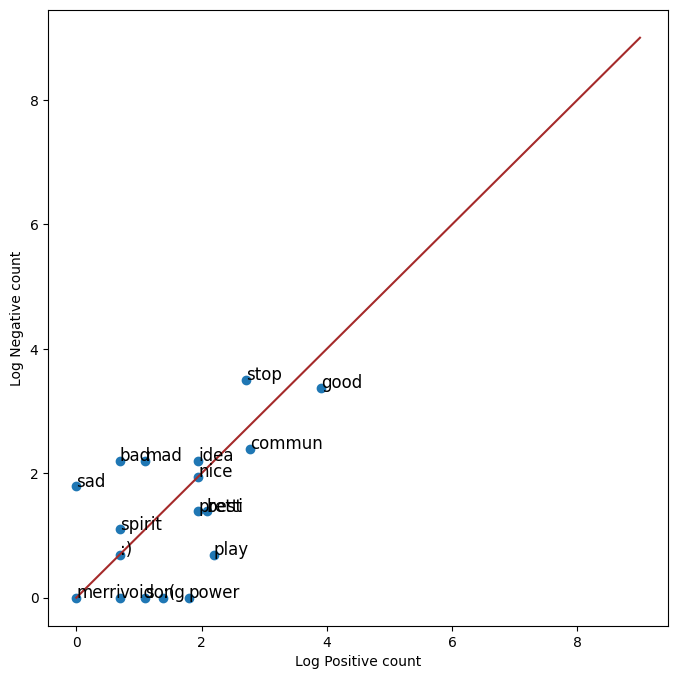

In [150]:
fig, ax = plt.subplots(figsize = (8, 8))

# convert positive raw counts to logarithmic scale. we add 1 to avoid log(0)
x = np.log([x[1] + 1 for x in data])

# do the same for the negative counts
y = np.log([x[2] + 1 for x in data])

# Plot a dot for each pair of words
ax.scatter(x, y)

# assign axis labels
plt.xlabel("Log Positive count")
plt.ylabel("Log Negative count")

# Add the word as the label at the same position as you added the points just before
for i in range(0, len(data)):
    ax.annotate(data[i][0], (x[i], y[i]), fontsize=12)

ax.plot([0, 9], [0, 9], color = 'brown') # Plot the red line that divides the 2 areas.
plt.show()

## Based on the frequency, let's create features for the dataset.

In [151]:
def extract_features(tweet, freqs):
    '''
        tweet: a list of words for one tweet
        freqs: a dictionary corresponding to the frequencies of each tuple (word, label)
        x: a feature vector of dimension (1,3)
    '''
    # process_tweet tokenizes, stems, and removes stopwords
    word_l = process_tweet(tweet)
    # 3 elements in the form of a 1 x 3 vector
    x = np.zeros((1, 3))

    #bias term is set to 1
    x[0,0] = 1

    # loop through each word in the list of words
    for word in word_l:

        # increment the word count for the positive label 1
        x[0,1] += freqs.get((word, 1.0),0)

        # increment the word count for the negative label 0
        x[0,2] += freqs.get((word, 0.0),0)

    assert(x.shape == (1, 3))
    return x

In [152]:
train_x = training_tweets
tmp1 = extract_features(train_x[0], freqs)
print(tmp1)

[[1.000e+00 2.284e+03 2.482e+03]]


In [153]:
tmp2 = extract_features('This batch is the best batch', freqs)
print(tmp2)

[[ 1. 11.  3.]]


In [154]:
# collect the features 'x' and stack them into a matrix 'X'
X = np.zeros((len(train_x), 3))
for i in range(len(train_x)):
    X[i, :]= extract_features(train_x[i], freqs)

# training labels corresponding to X
train_y = np.append(np.ones((len(positive_train), 1)), np.zeros((len(negative_train), 1)), axis=0)
Y = np.ravel(train_y,order='C')

In [155]:
X.shape

(1514, 3)

In [156]:
X[:5]

array([[1.000e+00, 2.284e+03, 2.482e+03],
       [1.000e+00, 2.470e+03, 2.766e+03],
       [1.000e+00, 1.605e+03, 1.805e+03],
       [1.000e+00, 6.020e+02, 6.350e+02],
       [1.000e+00, 2.454e+03, 2.622e+03]])

In [157]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression().fit(X, Y)

print("Training Accuracy: ",clf.score(X, Y))

Training Accuracy:  0.678335535006605


In [158]:
def predict_custom_tweet(tweet, freqs):
    x = extract_features(tweet,freqs)
    y_pred = clf.predict(x)
    return y_pred

# test your function
list_of_tweets = ['\033[92m'+'Thank God coronovirus is over',
                  '\033[91m'+'This is seriously ridiculous. Stop hoarding',
                  '\033[92m'+'Government efforts are great.',
                  '\033[93m'+'Nonsense', #anomaly in classification
                  '\033[91m'+'Panic-buying is pushing up prices.#coronavirus',
                  '\033[92m'+'THANK YOU to make hand sanitizer in distillery amid outbreak']

for tweet in list_of_tweets:
    print( '%s -> %f' % (tweet, predict_custom_tweet(tweet, freqs)))

Thank God coronovirus is over -> 0.000000
This is seriously ridiculous. Stop hoarding -> 0.000000
Government efforts are great. -> 0.000000
Nonsense -> 0.000000
Panic-buying is pushing up prices.#coronavirus -> 0.000000
THANK YOU to make hand sanitizer in distillery amid outbreak -> 1.000000


/tmp/ipython-input-130457664.py:15: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

/tmp/ipython-input-130457664.py:15: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

/tmp/ipython-input-130457664.py:15: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

/tmp/ipython-input-130457664.py:15: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this o

In [159]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Ensure train_x and Y are available from previous steps
# If train_x is not explicitly defined in the current notebook state, this cell might fail.
# Assuming train_x is a list of preprocessed tweets (strings).

# Create a pipeline with TfidfVectorizer and Multinomial Naive Bayes classifier
naive_bayes_clf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB()),
])

# Train the Naive Bayes model
naive_bayes_clf.fit(train_x, Y)

# Predict on the training data to evaluate training accuracy
y_pred_train_nb = naive_bayes_clf.predict(train_x)
train_accuracy_nb = accuracy_score(Y, y_pred_train_nb)

print(f"Training Accuracy for Naive Bayes: {train_accuracy_nb:.4f}")

Training Accuracy for Naive Bayes: 0.9709


In [160]:
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Create a pipeline with TfidfVectorizer and an SVM classifier
svm_clf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', SVC(kernel='linear', random_state=42)), # Using a linear kernel for text classification
])

# Train the SVM model
print("Training SVM model...")
svm_clf.fit(train_x, Y)
print("SVM model training complete.")

# Predict on the training data to evaluate training accuracy
y_pred_train_svm = svm_clf.predict(train_x)
train_accuracy_svm = accuracy_score(Y, y_pred_train_svm)

print(f"Training Accuracy for SVM: {train_accuracy_svm:.4f}")

Training SVM model...
SVM model training complete.
Training Accuracy for SVM: 0.9617


In [161]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Import Required Libraries
# ---------------------------
import pandas as pd
import numpy as np
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# ---------------------------
# Load Dataset
# ---------------------------
# Expecting CSV with columns: "OriginalTweet", "sentiment"
df = pd.read_csv("corona_tweets.csv")

# ---------------------------
# Text Cleaning Function
# ---------------------------
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # Remove URLs
    text = re.sub(r'@\w+|#', '', text)  # Remove mentions & hashtags
    text = re.sub(r'[^A-Za-z\s]', '', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_text"] = df["OriginalTweet"].apply(clean_text)

# ---------------------------
# Encode Target Labels
# ---------------------------
le = LabelEncoder()
df["label"] = le.fit_transform(df["Sentiment"])
print(f"Number of unique sentiment classes: {len(le.classes_)}")

# ---------------------------
# Train-Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"], test_size=0.2, random_state=42
)

# ---------------------------
# Tokenization
# ---------------------------
vocab_size = 10000
max_len = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

# ---------------------------
# LSTM Model
# ---------------------------
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')  # Updated to match number of unique sentiment classes
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# ---------------------------
# Train Model
# ---------------------------
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    verbose=1
)

# ---------------------------
# Evaluate Model
# ---------------------------
loss, accuracy = model.evaluate(X_test_pad, y_test, verbose=1)
print(f"\nTest Accuracy: {accuracy:.4f}")

# ---------------------------
# Predict on New Tweet
# ---------------------------
def predict_sentiment(tweet):
    cleaned = clean_text(tweet)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding="post")
    pred = model.predict(padded)
    label = np.argmax(pred)
    return le.inverse_transform([label])[0]

print(predict_sentiment("Covid situation seems to be improving!"))

Number of unique sentiment classes: 5
Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.2482 - loss: 1.5941 - val_accuracy: 0.2664 - val_loss: 1.5833
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2868 - loss: 1.5807 - val_accuracy: 0.2516 - val_loss: 1.5825
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2679 - loss: 1.5807 - val_accuracy: 0.2664 - val_loss: 1.5812
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2728 - loss: 1.5779 - val_accuracy: 0.2664 - val_loss: 1.5825
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2670 - loss: 1.5739 - val_accuracy: 0.2664 - val_loss: 1.5877
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2701 - loss: 1.5871

Test Accuracy: 0.2789
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Negative


In [ ]:
#Hyperparamater Tuning (Keras Tuner)
!pip install keras-tuner --quiet

import kerastuner as kt
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.models import Sequential

def build_model(hp):
    model = Sequential()

    # Embedding size
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=hp.Int("embed_dim", min_value=64, max_value=256, step=64),
        input_length=max_len
    ))

    # LSTM units
    model.add(LSTM(
        units=hp.Int("lstm_units", min_value=64, max_value=256, step=64),
        return_sequences=False
    ))

    # Dense layer size
    model.add(Dense(
        units=hp.Int("dense_units", min_value=32, max_value=128, step=32),
        activation='relu'
    ))

    # Dropout
    model.add(Dropout(hp.Float("dropout", 0.2, 0.5, step=0.1)))

    model.add(Dense(3, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='tuner_dir',
    project_name='covid_sentiment_lstm'
)

tuner.search(
    X_train_pad, y_train,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

best_model = tuner.get_best_models(1)[0]
best_model.summary()


In [162]:
# Bidirectional LSTM model
from tensorflow.keras.layers import Bidirectional

bi_lstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

bi_lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_bi = bi_lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning:

Argument `input_length` is deprecated. Just remove it.



38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.1673 - loss: nan - val_accuracy: 0.1678 - val_loss: nan
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1534 - loss: nan - val_accuracy: 0.1678 - val_loss: nan
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1568 - loss: nan - val_accuracy: 0.1678 - val_loss: nan
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1652 - loss: nan - val_accuracy: 0.1678 - val_loss: nan
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1508 - loss: nan - val_accuracy: 0.1678 - val_loss: nan


In [163]:
# CNN model for Text classification
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

cnn_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),

    # Convolution for text patterns
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

cnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_cnn = cnn_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.2555 - loss: nan - val_accuracy: 0.2664 - val_loss: nan
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2690 - loss: nan - val_accuracy: 0.2664 - val_loss: nan
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2659 - loss: nan - val_accuracy: 0.2664 - val_loss: nan
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2765 - loss: nan - val_accuracy: 0.2664 - val_loss: nan
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2681 - loss: nan - val_accuracy: 0.2664 - val_loss: nan


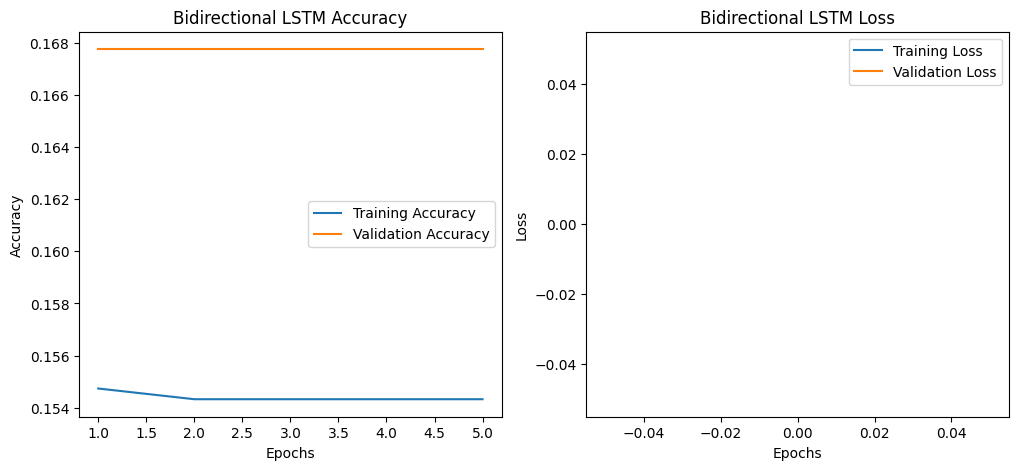

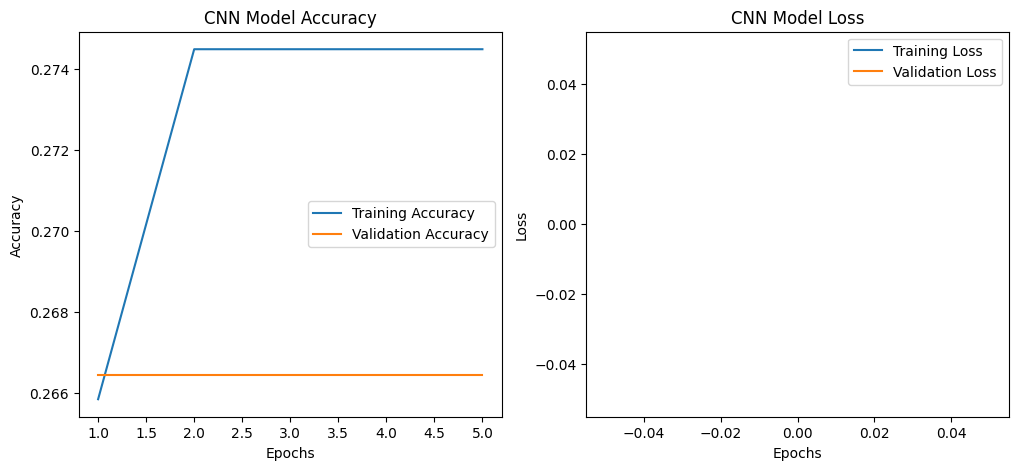

In [164]:
# Plot training accuracy and loss
import matplotlib.pyplot as plt

def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title(f'{title} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Example usage:
plot_history(history_bi, "Bidirectional LSTM")
plot_history(history_cnn, "CNN Model")
